In [19]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from app.config import PLAYER_CHOICE

from scipy.stats import chi2_contingency
import statsmodels.api

In [2]:
def filter_by_players(df):
    chosen_player_matrix = None

    for name in PLAYER_CHOICE:
        current_matrix = df['PLAYER_NAME'] == name
        if chosen_player_matrix is None:
            chosen_player_matrix = current_matrix
        else:
            chosen_player_matrix = chosen_player_matrix | current_matrix

    return df[chosen_player_matrix]

# Load dataset

In [3]:
ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/ds-training-nba/nba_shot_data/resolve/main/raw_merged/merged_dataset.parquet"
)
df = ds["train"].to_pandas()

In [4]:
df.head(2)

,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION,VIDEO_AVAILABLE_FLAG,year,is_playoffs,shotValue
0,4,PT11M39.00S,1,1610612741,CHI,23,Rodman,D. Rodman,0,0,...,0.0,NaN,1.610613e+09,Boston,Celtics,BOS,0.0,1996,False,NaN
1,6,PT11M39.00S,1,1610612741,CHI,23,Rodman,D. Rodman,0,15,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1996,False,NaN


In [5]:
df = filter_by_players(df)

In [6]:
# Drop unnecessary columns
irrelevant_cols = ['GRID_TYPE', 'SHOT_ATTEMPTED_FLAG', 'videoAvailable', 'VIDEO_AVAILABLE_FLAG']
duplicate_cols = ['actionNumber', 'clock', 'period', 'teamId', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'gameId', 'EVENTNUM',
                 'PERIOD_y', 'WCTIMESTRING', 'PCTIMESTRING', 'SCORE', 'SCOREMARGIN', 'shotValue']

df = df.drop(irrelevant_cols, axis=1)
df = df.drop(duplicate_cols, axis=1)

# General statistics

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 556754 entries, 1559 to 8204391
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   teamTricode                556754 non-null  str    
 1   shotDistance               556754 non-null  int64  
 2   shotResult                 537952 non-null  str    
 3   isFieldGoal                556754 non-null  int64  
 4   scoreHome                  453718 non-null  float64
 5   scoreAway                  453718 non-null  float64
 6   pointsTotal                556754 non-null  int64  
 7   location                   556754 non-null  str    
 8   description                556754 non-null  str    
 9   actionType                 537952 non-null  str    
 10  subType                    537952 non-null  str    
 11  actionId                   556754 non-null  int64  
 12  GAME_ID_x                  556754 non-null  float64
 13  GAME_EVENT_ID              556754 non-nul

In [26]:
df.describe()

,GAME_ID,GAME_EVENT_ID,PLAYER_ID,TEAM_ID,PERIOD_x,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,...,PERSON1TYPE,PLAYER1_ID,PLAYER1_TEAM_ID,PERSON2TYPE,PLAYER2_ID,PLAYER2_TEAM_ID,PERSON3TYPE,PLAYER3_ID,PLAYER3_TEAM_ID,year
count,4.108150e+05,410815.000000,4.108150e+05,4.108150e+05,410815.000000,410815.000000,410815.000000,410815.000000,410815.000000,410815.000000,...,410808.000000,4.108080e+05,4.108080e+05,410808.000000,4.108080e+05,8.588600e+04,410808.000000,4.108080e+05,3.764100e+04,410815.000000
mean,2.423846e+07,264.233886,1.236887e+05,1.610613e+09,2.449412,5.186753,28.695814,11.748023,-2.177248,84.166659,...,4.500725,1.236874e+05,1.610613e+09,0.935734,5.248054e+04,1.610613e+09,0.409768,3.047433e+04,1.610613e+09,2012.001541
std,6.972339e+06,170.563290,2.541631e+05,7.306194e+00,1.138950,3.394262,17.470582,9.624347,96.800209,88.208995,...,0.500000,2.541650e+05,7.306193e+00,1.834311,2.425604e+05,7.300759e+00,1.299012,1.956002e+05,8.423151e+00,6.907589
min,2.000001e+07,1.000000,7.080000e+02,1.610613e+09,1.000000,0.000000,0.000000,0.000000,-250.000000,-51.000000,...,4.000000,7.080000e+02,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,1996.000000
25%,2.090008e+07,108.000000,1.717000e+03,1.610613e+09,1.000000,2.000000,13.000000,2.000000,-51.000000,9.000000,...,4.000000,1.717000e+03,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,2007.000000
50%,2.150031e+07,263.000000,2.548000e+03,1.610613e+09,2.000000,5.000000,29.000000,11.000000,0.000000,49.000000,...,5.000000,2.548000e+03,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,2012.000000
75%,2.220020e+07,390.000000,2.019350e+05,1.610613e+09,3.000000,8.000000,44.000000,20.000000,43.000000,152.000000,...,5.000000,2.019350e+05,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,0.000000,0.000000e+00,1.610613e+09,2017.000000
max,4.990009e+07,860.000000,1.629029e+06,1.610613e+09,8.000000,12.000000,59.000000,87.000000,250.000000,867.000000,...,5.000000,1.629029e+06,1.610613e+09,5.000000,1.642461e+06,1.610613e+09,5.000000,1.642419e+06,1.610613e+09,2024.000000


# Data exploration

## Distance

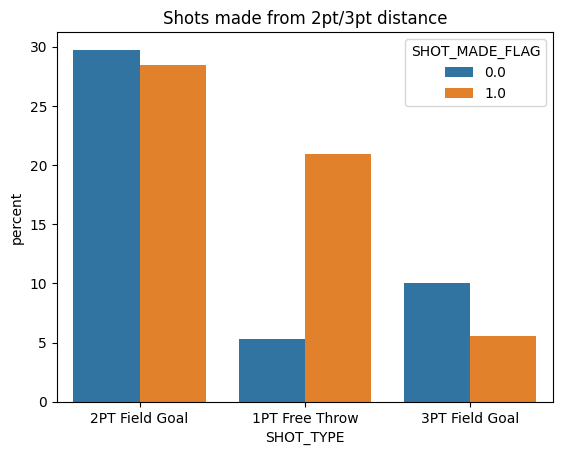

In [8]:
sns.countplot(df, x='SHOT_TYPE', hue='SHOT_MADE_FLAG', stat='percent')
plt.title('Shots made from 2pt/3pt distance')
plt.show()

' 
We can see that in general the amount of shots made from 2 pt distance is significantly higher than 3 pt shots.
In addition, the probability to hit, is higher for the shorter distance
'

In [16]:
test_stats, p, dof, expected = chi2_contingency(cont_table)
print(test_stats, p, dof)

54157.6964470395 0.0 2


The p-score is close to 0 zero. We reject H0 (shot type is not significant for the result)

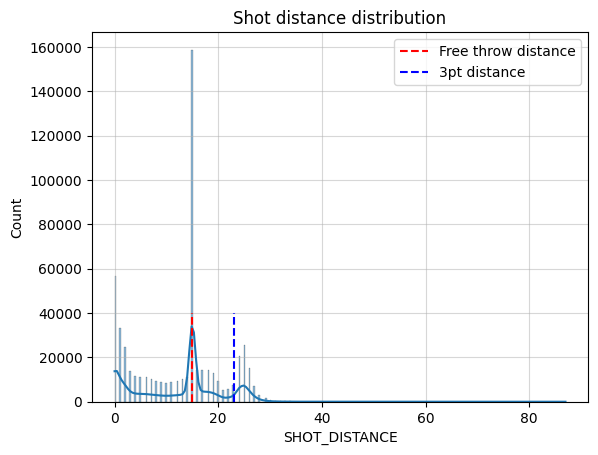

In [27]:
# Distribution of distance

sns.histplot(df, x='SHOT_DISTANCE', kde=True)
plt.plot([15,15], [0,40000], 'r--', label='Free throw distance')
plt.plot([23,23], [0,40000], 'b--', label='3pt distance')
plt.title('Shot distance distribution')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

We can see 3 main clusters for the distance. The most shots are done close to 0 ft. 
Followed by shots done close to the 3pt line and shots around the free throw distance. 
Some extremely far shots are visible, but the are very rare. It should be checked, if these are realistic 
(they might be deperation shots in the last seconds of the game)

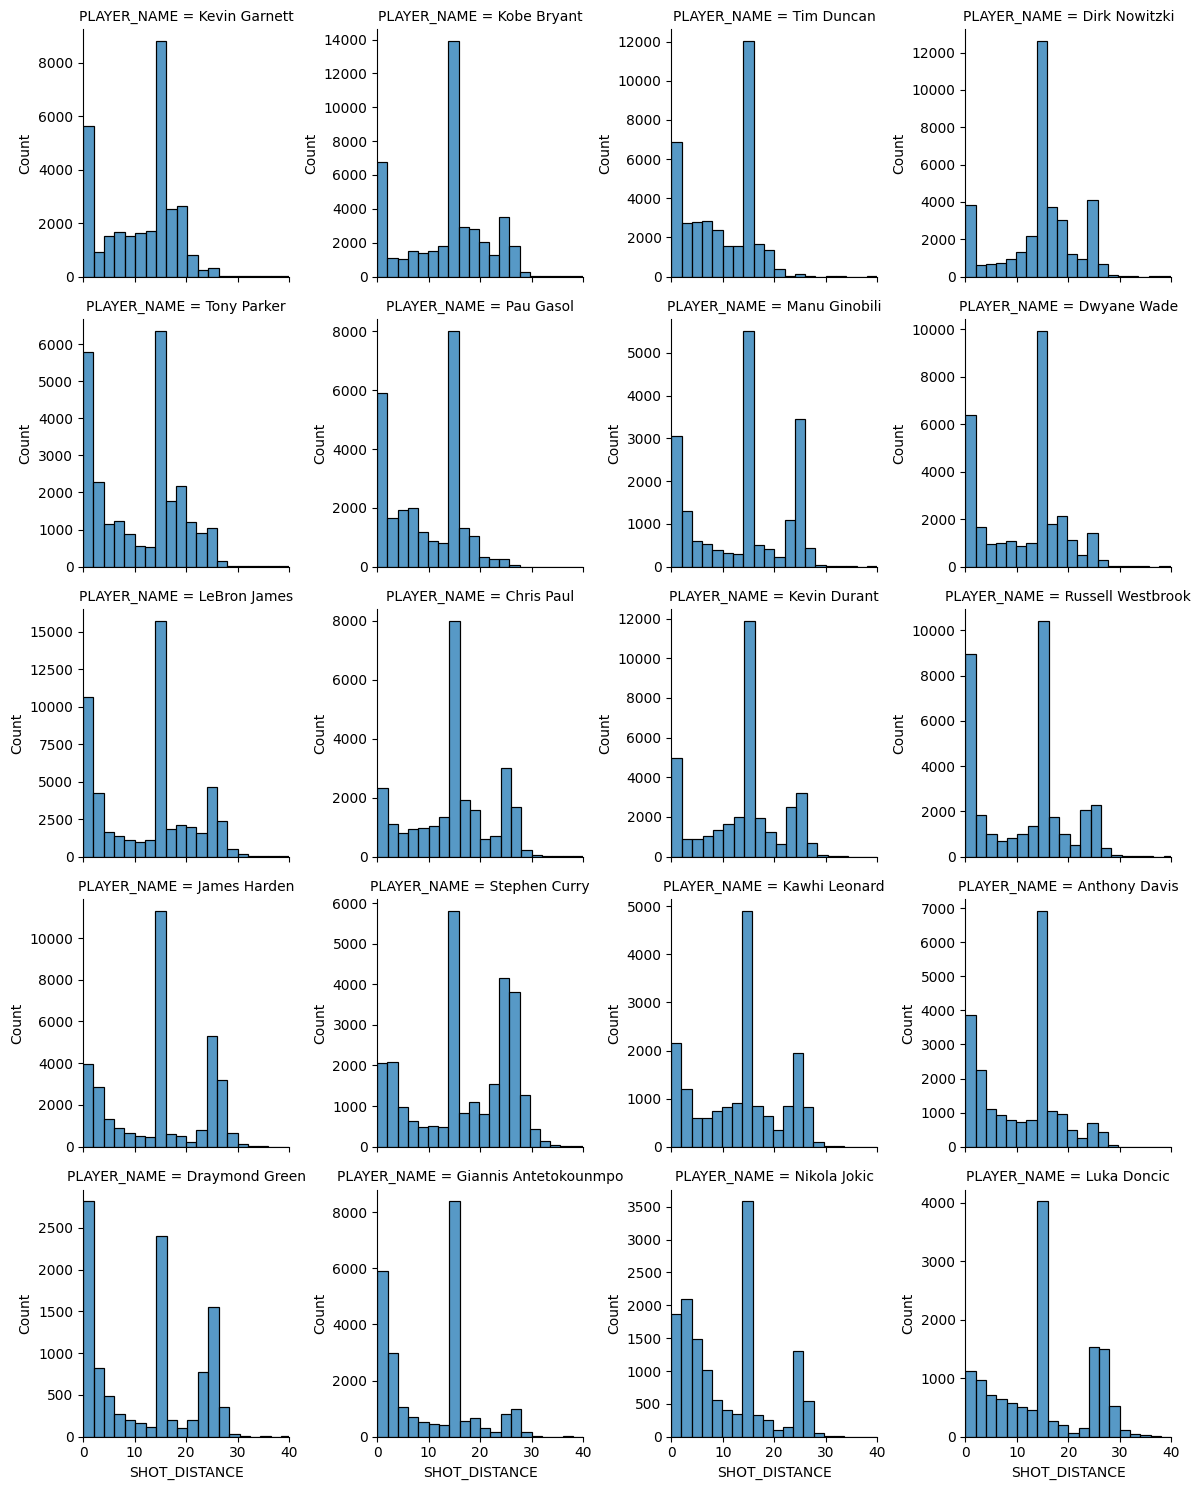

In [28]:
g = sns.FacetGrid(df, col='PLAYER_NAME', col_wrap=4, height=3, xlim=[0,40], sharey=False)
g.map_dataframe(sns.histplot, x="SHOT_DISTANCE", binwidth=2)

plt.show()

We can clearly see a preference for different players on the shot distance. Some Prefer jump shots, some 3pt shots, 
some are very generalized like Dirk Nowitzki

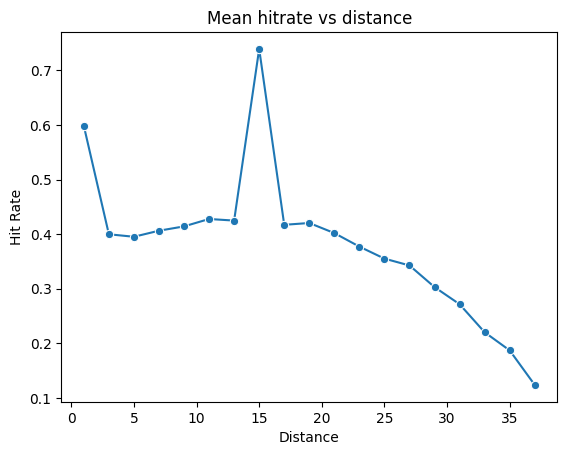

In [23]:
df['dist_bin'] = pd.cut(df['SHOT_DISTANCE'], bins=np.arange(0, 40, 2))

# compute hit rate
bin_stats = (
    df.groupby('dist_bin')['SHOT_MADE_FLAG']
    .mean()
    .reset_index()
)
bin_stats['mid'] = bin_stats['dist_bin'].apply(lambda x: x.mid)

sns.lineplot(data=bin_stats, x='mid', y='SHOT_MADE_FLAG', marker='o')
plt.xlabel('Distance')
plt.ylabel('Hit Rate')
plt.title('Mean hitrate vs distance')
plt.show()

In [24]:
# ANOVA test for significance of distance
result = statsmodels.formula.api.ols('SHOT_DISTANCE ~ SHOT_MADE_FLAG', data=df.dropna(subset=['SHOT_DISTANCE', 'SHOT_MADE_FLAG'])).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

,df,sum_sq,mean_sq,F,PR(>F)
SHOT_MADE_FLAG,1.0,3.803183e+05,380318.267627,5457.59642,0.0
Residual,556752.0,3.879784e+07,69.686037,NaN,NaN


Text(0.5, 1.0, 'Mean hitrate vs distance per player')

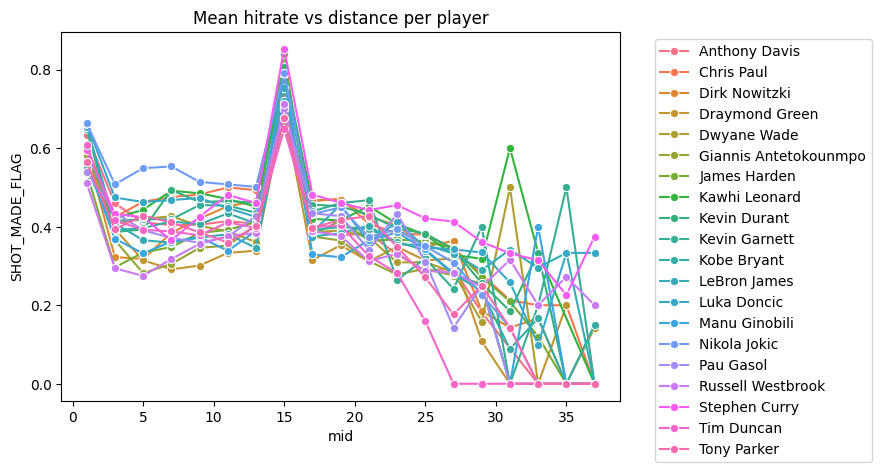

In [25]:
bin_stats = (
    df.groupby(['dist_bin', 'PLAYER_NAME'])['SHOT_MADE_FLAG']
    .mean()
    .reset_index()
)
bin_stats['mid'] = bin_stats['dist_bin'].apply(lambda x: x.mid)

sns.lineplot(data=bin_stats, x='mid', y='SHOT_MADE_FLAG', marker='o', hue='PLAYER_NAME')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Mean hitrate vs distance per player')
#g = sns.FacetGrid(bin_stats, col='PLAYER_NAME', col_wrap=4, height=3, xlim=[0,40], sharey=False)
#g.map_dataframe(sns.lineplot, x='mid', y='SHOT_MADE_FLAG')
#plt.show()

## Coordinates

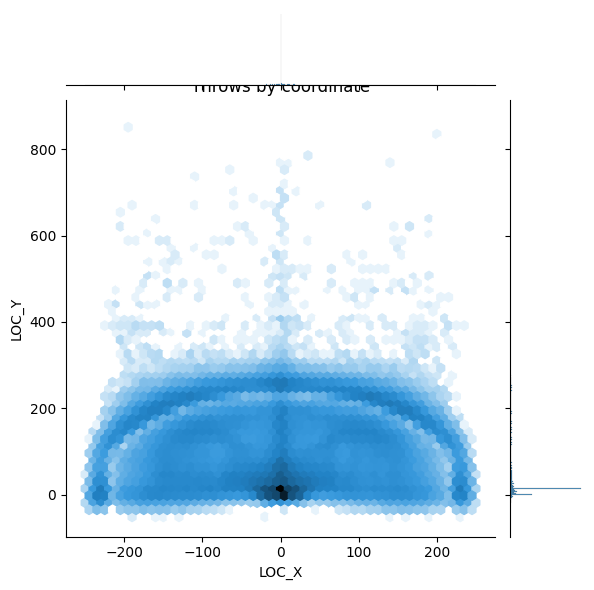

In [26]:
sns.jointplot(df, x='LOC_X', y='LOC_Y', kind="hex", joint_kws={'norm': 'log'})
plt.title('Throws by coordinate')
plt.show()

## Angle

In [92]:
# Compute shot angle in degrees, by coordinates
df['shot_angle'] = np.degrees(np.arctan2(df['LOC_X'], df['LOC_Y']))

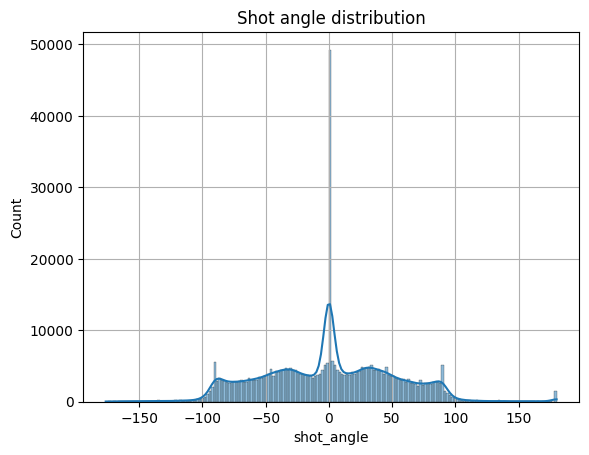

In [97]:
sns.histplot(df, x='shot_angle', kde=True)
plt.grid()
plt.title('Shot angle distribution')

plt.show()

A very high amount is at angle 0, these are probably all jump shots and free throws. The other angles are relatively equally
distributed. The shots at angles about 90° might be a bit questionable

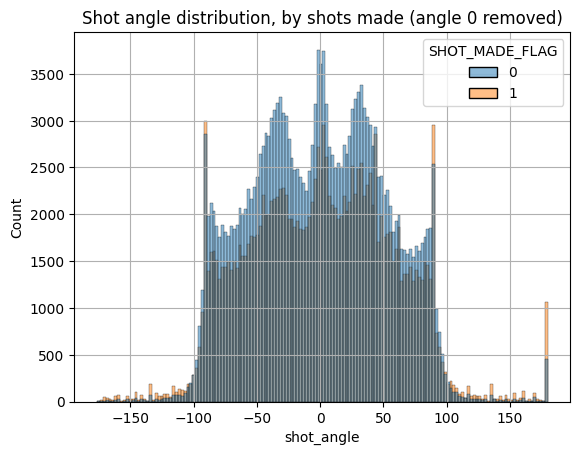

In [104]:
sns.histplot(df[~(df['shot_angle'] == 0)], x='shot_angle', hue='SHOT_MADE_FLAG')
plt.grid()
plt.title('Shot angle distribution, by shots made (angle 0 removed)')

plt.show()

From this plot we cannot see a clear influence of angle on the hit chance

## Shot types

In [108]:
df['ACTION_TYPE'].value_counts()

ACTION_TYPE
Jump Shot                      174742
Layup Shot                      41466
Driving Layup Shot              33486
Pullup Jump shot                26838
Step Back Jump shot             14350
                                ...  
Jump Bank Hook Shot                18
Running Bank Hook Shot             16
Turnaround Finger Roll Shot        15
Running Tip Shot                   14
Putback Reverse Dunk Shot           1
Name: count, Length: 70, dtype: int64

Text(0.5, 1.0, 'Count of most present shot types by ACTION_TYPE')

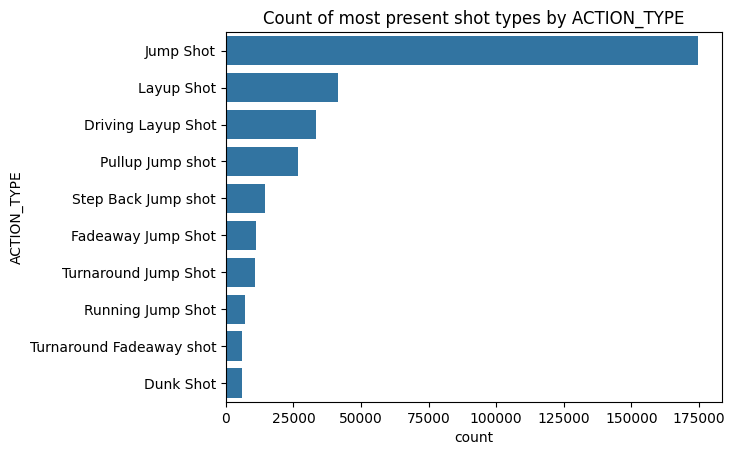

In [112]:
sns.countplot(df, y='ACTION_TYPE', order=df.ACTION_TYPE.value_counts().iloc[:10].index)
plt.title('Count of most present shot types by ACTION_TYPE')

Text(0.5, 1.0, 'Count of most present shot types by actionType')

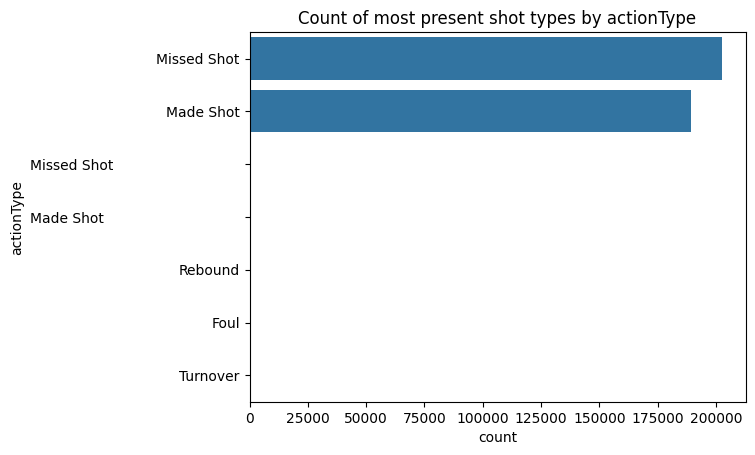

In [114]:
sns.countplot(df, y='actionType')
plt.title('Count of most present shot types by actionType')

In [116]:
df['actionType'].value_counts()

actionType
Missed Shot                                 202565
Made Shot                                   189250
Missed Shot                                     19
Made Shot                                       18
Rebound                                          2
Foul                                             1
Turnover                                         1
Name: count, dtype: int64

In [126]:
df['description'].dropna().apply(lambda x: "foul" in x).sum()

np.int64(0)